#  Análisis de Datos Composicionales (CoDa)
Proyecta los datos proporcionales del símplex al espacio euclidiano utilizando la transformación Centered Log-Ratio (CLR).

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from xrf.transforms.coda import Clr_Transformer
from xrf.config import Xrf_Preprocessing_Config

In [8]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

# Data path
# Load raw data

DATA_DIR = PROJECT_DIR / "data" / "xrf"
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"
PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
config = Xrf_Preprocessing_Config()

# Usamos valid_pixels del paso anterior (o generamos mock data)
if "valid_pixels" not in locals():
    valid_pixels = np.random.rand(5000, 4) * 10

# Aplicar transformación CLR
clr_data = Clr_Transformer.Apply_Clr_Transform(valid_pixels, Delta=config.Zero_Replacement_Delta)
print(f"Dimensiones de los datos transformados: {clr_data.shape}")

# 3. Guardar datos transformados para el cuaderno 03
np.save(PROCESSED_DATA_DIR / "page_001_clr.npy", clr_data)

Dimensiones de los datos transformados: (5000, 4)


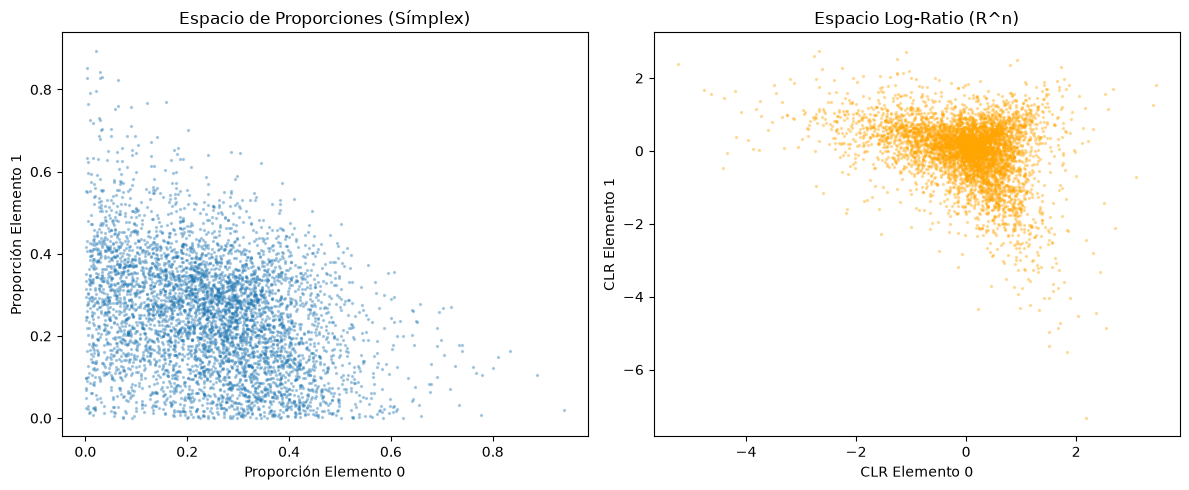

In [12]:
# Visualización comparativa de distribuciones (Canal 0 vs Canal 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Espacio original (Proporciones / Símplex)
proportions = valid_pixels / np.sum(valid_pixels, axis=1, keepdims=True)
ax1.scatter(proportions[:, 0], proportions[:, 1], alpha=0.3, s=2)
ax1.set_title("Espacio de Proporciones (Símplex)")
ax1.set_xlabel("Proporción Elemento 0")
ax1.set_ylabel("Proporción Elemento 1")

# Espacio euclidiano CLR
ax2.scatter(clr_data[:, 0], clr_data[:, 1], alpha=0.3, s=2, color="orange")
ax2.set_title("Espacio Log-Ratio (R^n)")
ax2.set_xlabel("CLR Elemento 0")
ax2.set_ylabel("CLR Elemento 1")

plt.tight_layout()
plt.show()